<a href="https://colab.research.google.com/github/sharvani1357/NLP/blob/main/spam_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Real-World Scenario
You are working as a Data Scientist in an Email Security Company.
Your task is to build an Intelligent Email Analysis System that can:
Detect spam emails
Understand sentiment
Extract important entities
Predict next words
Build a chatbot for support
Columns:
label → spam / ham
message → text

🧠 TASK 1
Objective
Understand dataset patterns.
Tasks
Check dataset shape
Count spam vs ham
Find average message length
Plot word frequency

Dataset Shape: (5572, 2)

Spam vs Ham Count:
label
ham     4825
spam     747
Name: count, dtype: int64


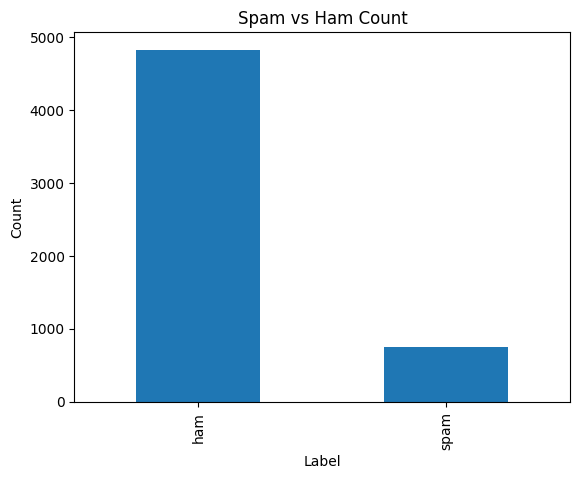


Average Message Length: 80.11880832735105

Average Length (Spam vs Ham):
label
ham      71.023627
spam    138.866131
Name: message_length, dtype: float64


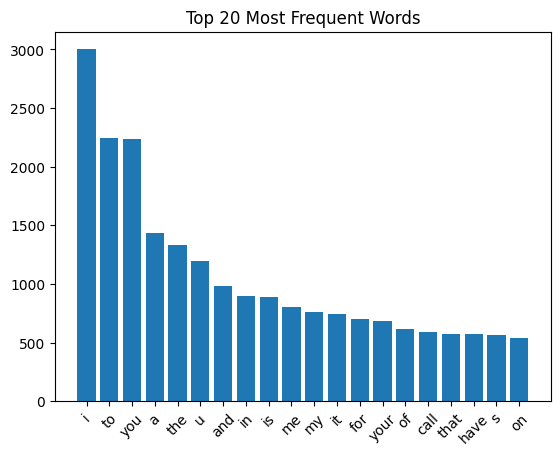

In [ ]:

# TASK 1: Exploratory Data Analysis
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only required columns
df = df.rename(columns={df.columns[0]: 'label', df.columns[1]: 'message'})
df = df[['label', 'message']]
print("Dataset Shape:", df.shape)


# Spam vs Ham Count

print("\nSpam vs Ham Count:")
print(df['label'].value_counts())

# Plot
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Count")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# 4. Message Length Analysis
df['message_length'] = df['message'].astype(str).apply(len)
print("\nAverage Message Length:", df['message_length'].mean())
print("\nAverage Length (Spam vs Ham):")
print(df.groupby('label')['message_length'].mean())
# 5. Word Frequency
# Combine all messages
all_words = " ".join(df['message'].astype(str)).lower()

# Clean text
words = re.findall(r'\b\w+\b', all_words)

# Count frequency
word_counts = Counter(words)

# Top 20 words
common_words = word_counts.most_common(20)

# Separate words and counts
words = [w for w, c in common_words]
counts = [c for w, c in common_words]

# Plot
plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

🧹 TASK 2 — Text Preprocessing Pipeline
Build a reusable function that performs:
Lowercasing
Tokenization
Stopword removal
Punctuation removal
Lemmatization
Bonus
Create a single pipeline function
def preprocess(text):
    ...
    return cleaned_text

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
#Preprocessing Function
def preprocess(text):
    #Lowercasing
    text = text.lower()

    #Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    #Tokenization
    tokens = word_tokenize(text)

    #Stopword removal
    tokens = [word for word in tokens if word not in stop_words]

    #Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    #Join back to string
    cleaned_text = " ".join(tokens)

    return cleaned_text

In [ ]:
import nltk
nltk.download('punkt_tab')
#Example
sample = "Hello!!! This is an example message, running quickly."
print(preprocess(sample))

hello example message running quickly


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


🔢 TASK 3 — Feature Engineering (BoW vs TF-IDF)
Tasks
Convert text using:
CountVectorizer (BoW)
TfidfVectorizer
Compare:
Feature size
Sparsity
Model performance

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import numpy as np

In [ ]:
X = df['cleaned_message']   # from Task 2
y = df['label'].map({'ham':0, 'spam':1})  # convert to numbers

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 2. Bag of Words (BoW)
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [ ]:
# 3. TF-IDF
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# 4. Feature Size
print("BoW Feature Size:", X_train_bow.shape)
print("TF-IDF Feature Size:", X_train_tfidf.shape)

BoW Feature Size: (4457, 7832)
TF-IDF Feature Size: (4457, 7832)


In [ ]:
# 5. Sparsity
def sparsity(matrix):
    return 1.0 - (matrix.count_nonzero() / (matrix.shape[0] * matrix.shape[1]))

print("BoW Sparsity:", sparsity(X_train_bow))
print("TF-IDF Sparsity:", sparsity(X_train_tfidf))

BoW Sparsity: 0.9989191635519341
TF-IDF Sparsity: 0.9989191635519341


In [ ]:
# 6. Model Training & Evaluation
model_bow = MultinomialNB()
model_bow.fit(X_train_bow, y_train)
y_pred_bow = model_bow.predict(X_test_bow)

model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

# Accuracy
print("\nBoW Accuracy:", accuracy_score(y_test, y_pred_bow))
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))


BoW Accuracy: 0.9802690582959641
TF-IDF Accuracy: 0.9641255605381166


🤖 TASK 4 — Baseline Model
Build a simple model:
Algorithm: Logistic Regression
Steps
Train model
Evaluate accuracy
Confusion matrix


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
# 1. Vectorization (TF-IDF)
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 2. Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.9506726457399103

Confusion Matrix:
 [[961   4]
 [ 51  99]]


📈 TASK 5 — Model Comparison
Train multiple models:
Naive Bayes
Logistic Regression
SVM
Compare:
Accuracy
Precision
Recall
F1-score

In [ ]:


from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 1. Use TF-IDF Features
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


# 2. Initialize Models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

# 3. Train & Evaluate
for name, model in models.items():
    # Train
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)


Naive Bayes
Accuracy: 0.9641255605381166
Precision: 1.0
Recall: 0.7333333333333333
F1-score: 0.8461538461538461

Logistic Regression
Accuracy: 0.9506726457399103
Precision: 0.9611650485436893
Recall: 0.66
F1-score: 0.782608695652174

SVM
Accuracy: 0.9748878923766816
Precision: 0.9841269841269841
Recall: 0.8266666666666667
F1-score: 0.8985507246376812


### 🧠 TASK 6 — Hyperparameter Tuning
Use:
GridSearchCV
Tune:
C (Logistic Regression)
kernel (SVM)
### 📊 TASK 7 — Advanced Feature Engineering
Implement:
N-grams (bigram, trigram)
Compare performance:
ngram_range=(1,2)
ngram_range=(1,3)
### 🧩 TASK 8 — Word Embeddings (Word2Vec)
Tasks
Train Word2Vec model
Convert sentences → vectors (average embeddings)
Train classifier
### 😊 TASK 9 — Sentiment Analysis
Add new feature:
Sentiment score using TextBlob or VADER
Combine with TF-IDF.
### 🏷️ TASK 10 — Named Entity Recognition (NER)
Extract entities from messages:
Names
Organizations
Locations
Use:
spaCy
### 🔤 TASK 11 — Part-of-Speech Analysis
Tasks
Extract POS tags
Find most common verbs/nouns in spam
### 🔮 TASK 12 — Language Model (N-gram)
Build:
Bigram model to predict next word.
Example:
"win money now" → predict

In [ ]:
#Task6
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Logistic Regression tuning
lr_params = {'C': [0.1, 1, 10]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5)
lr_grid.fit(X_train_tfidf, y_train)

print("Best LR Params:", lr_grid.best_params_)
print("Best LR Score:", lr_grid.best_score_)

# SVM tuning
svm_params = {'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(), svm_params, cv=5)
svm_grid.fit(X_train_tfidf, y_train)

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM Score:", svm_grid.best_score_)

Best LR Params: {'C': 10}
Best LR Score: 0.9732985057349779
Best SVM Params: {'kernel': 'linear'}
Best SVM Score: 0.9766632443015105


In [ ]:
#Task7
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Bigram
tfidf_bigram = TfidfVectorizer(ngram_range=(1,2))
X_train_big = tfidf_bigram.fit_transform(X_train)
X_test_big = tfidf_bigram.transform(X_test)

# Trigram
tfidf_trigram = TfidfVectorizer(ngram_range=(1,3))
X_train_tri = tfidf_trigram.fit_transform(X_train)
X_test_tri = tfidf_trigram.transform(X_test)

model = LogisticRegression(max_iter=1000)

# Train Bigram
model.fit(X_train_big, y_train)
pred_big = model.predict(X_test_big)

# Train Trigram
model.fit(X_train_tri, y_train)
pred_tri = model.predict(X_test_tri)

print("Bigram Accuracy:", accuracy_score(y_test, pred_big))
print("Trigram Accuracy:", accuracy_score(y_test, pred_tri))

Bigram Accuracy: 0.9443946188340807
Trigram Accuracy: 0.9381165919282511


In [ ]:
from gensim.models import Word2Vec
import numpy as np

# Tokenize
tokenized = [text.split() for text in X_train]

# Train Word2Vec
w2v = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=1)

# Sentence to vector
def sentence_vector(sentence):
    words = sentence.split()
    vectors = [w2v.wv[w] for w in words if w in w2v.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_train_w2v = np.array([sentence_vector(s) for s in X_train])
X_test_w2v = np.array([sentence_vector(s) for s in X_test])

# Train classifier
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_w2v, y_train)

pred = model.predict(X_test_w2v)
print("Word2Vec Accuracy:", accuracy_score(y_test, pred))
!pip install gensim
from gensim.models import Word2Vec
import numpy as np

# Tokenize
tokenized = [text.split() for text in X_train]

# Train Word2Vec
w2v = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=1)

# Sentence to vector
def sentence_vector(sentence):
    words = sentence.split()
    vectors = [w2v.wv[w] for w in words if w in w2v.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_train_w2v = np.array([sentence_vector(s) for s in X_train])
X_test_w2v = np.array([sentence_vector(s) for s in X_test])

# Train classifier
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_w2v, y_train)

pred = model.predict(X_test_w2v)
print("Word2Vec Accuracy:", accuracy_score(y_test, pred))

Word2Vec Accuracy: 0.8654708520179372
Word2Vec Accuracy: 0.8654708520179372


In [ ]:
#task9
from textblob import TextBlob

# Sentiment score
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['cleaned_message'].apply(get_sentiment)

# Combine TF-IDF + sentiment
import numpy as np

X_train_sent = np.hstack((X_train_tfidf.toarray(), df.loc[X_train.index, 'sentiment'].values.reshape(-1,1)))
X_test_sent = np.hstack((X_test_tfidf.toarray(), df.loc[X_test.index, 'sentiment'].values.reshape(-1,1)))

model.fit(X_train_sent, y_train)
pred = model.predict(X_test_sent)

print("TF-IDF + Sentiment Accuracy:", accuracy_score(y_test, pred))

TF-IDF + Sentiment Accuracy: 0.9497757847533632


In [ ]:
#task10
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

# Example
print(extract_entities("Call Microsoft in New York now"))

[('Call Microsoft', 'ORG'), ('New York', 'GPE')]


In [ ]:
#task11
import nltk
from collections import Counter

nltk.download('averaged_perceptron_tagger_eng')

# Get POS tags
def get_pos(text):
    tokens = text.split()
    return nltk.pos_tag(tokens)

# Apply on spam messages
spam_texts = df[df['label']=='spam']['cleaned_message']

all_tags = []
for text in spam_texts:
    tags = get_pos(text)
    all_tags.extend(tags)

# Separate nouns & verbs
nouns = [word for word, tag in all_tags if tag.startswith('NN')]
verbs = [word for word, tag in all_tags if tag.startswith('VB')]

print("Top Nouns:", Counter(nouns).most_common(10))
print("Top Verbs:", Counter(verbs).most_common(10))

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Top Nouns: [('call', 259), ('txt', 117), ('claim', 107), ('text', 100), ('reply', 89), ('service', 72), ('tone', 63), ('week', 62), ('cash', 62), ('stop', 60)]
Top Verbs: [('call', 71), ('get', 51), ('guaranteed', 49), ('prize', 41), ('awarded', 38), ('stop', 33), ('send', 32), ('go', 31), ('win', 29), ('selected', 25)]


In [ ]:
#task12
from collections import defaultdict, Counter

# Build bigram model
def build_bigram(corpus):
    model = defaultdict(Counter)
    for sentence in corpus:
        words = sentence.split()
        for i in range(len(words)-1):
            model[words[i]][words[i+1]] += 1
    return model

bigram_model = build_bigram(X_train)

# Predict next word
def predict_next(word):
    if word in bigram_model:
        return bigram_model[word].most_common(1)[0][0]
    else:
        return None

# Example
print(predict_next("win"))


free
